In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv('cleaned_amazon_laptops.csv')

df.head()

,Title,Brand,Price,Rating,operating_system,ram,disk_size,Reviews,display_size
0,Mavark Dell Pro Max 18 Plus Mobile Workstation...,DELL,14999.00,NaN,Windows 11 Pro,24.0,32768.0,0,18.0
1,Mavark Alienware 18 Area-51 Gaming Laptop Ultr...,MAVARK,12999.00,NaN,Windows 11 Pro,96.0,24576.0,0,18.0
2,Mavark Lenovo ThinkPad P16 Gen 3 Mobile Workst...,LENOVO,11999.00,NaN,Windows 11 Pro,192.0,18432.0,0,16.0
3,Lenovo ThinkPad P17 Gen 2 Home & Business Lapt...,LENOVO,9999.99,NaN,Windows 11 Pro,16.0,8192.0,0,17.3
4,[2026] MSI Titan 18 HX Dragon Edition Norse My...,MSI,9889.00,NaN,Windows 11 Pro,128.0,8192.0,0,18.0


C:\Users\Hp\AppData\Local\Temp\ipykernel_7760\3995418560.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Brand', order=order, palette='viridis')


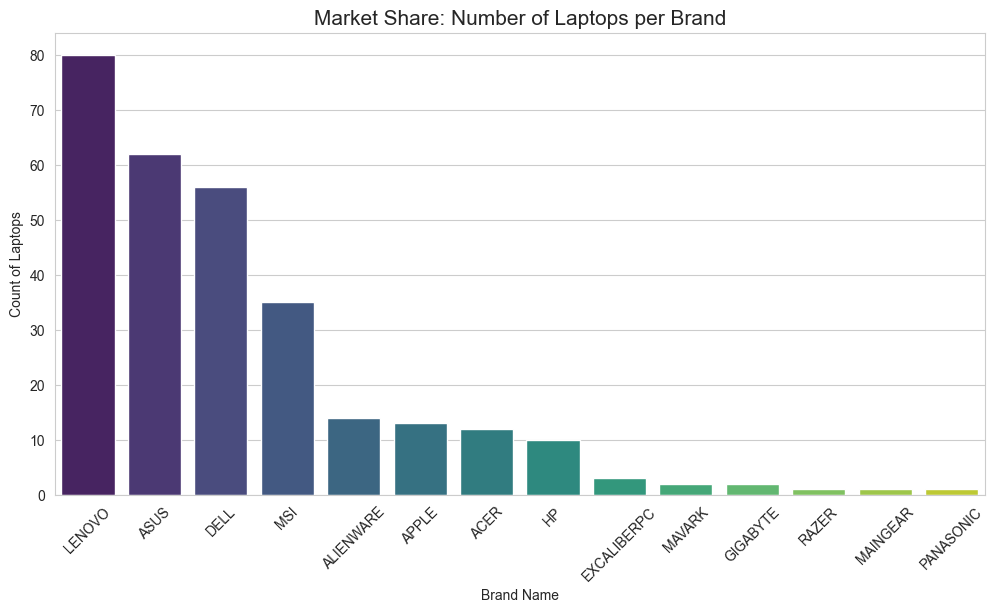

In [2]:
# 1. (Brand Distribution)
order = df['Brand'].value_counts().index  

sns.countplot(data=df, x='Brand', order=order, palette='viridis')
plt.title('Market Share: Number of Laptops per Brand', fontsize=15)
plt.xticks(rotation=45)
plt.xlabel('Brand Name')
plt.ylabel('Count of Laptops')
plt.show()

Market Share Analysis: Brand Distribution
Based on the chart above, we can observe the following:

Dominant Brands: Lenovo, ASUS, and Dell are the most frequent brands in this dataset, accounting for the vast majority of listings.

Niche Players: Brands like Apple, HP, and Acer have a much smaller presence in this specific Amazon scrape.

Observation: The high volume of Lenovo and ASUS suggest they might have a wider variety of models or higher availability in the current market segment being analyzed.

C:\Users\Hp\AppData\Local\Temp\ipykernel_7760\1753163601.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price.index, y=avg_price.values, palette='magma')


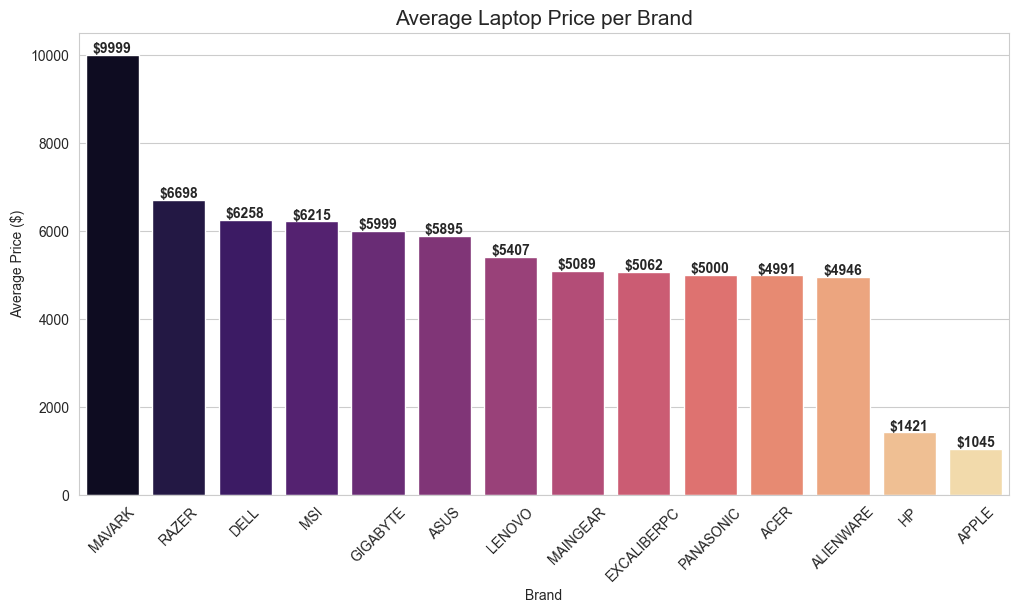

In [4]:
#  Average Price per Brand
avg_price = df.groupby('Brand')['Price'].mean().sort_values(ascending=False)

#   Bar Chart  
sns.barplot(x=avg_price.index, y=avg_price.values, palette='magma')

plt.title('Average Laptop Price per Brand', fontsize=15)
plt.xticks(rotation=45)
plt.ylabel('Average Price ($)')
plt.xlabel('Brand')

#adding value labels on top of bars
for i, v in enumerate(avg_price.values):
    plt.text(i, v + 50, f'${v:.0f}', ha='center', fontweight='bold')

plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_7760\3102592517.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Brand', y='Price', palette='magma')


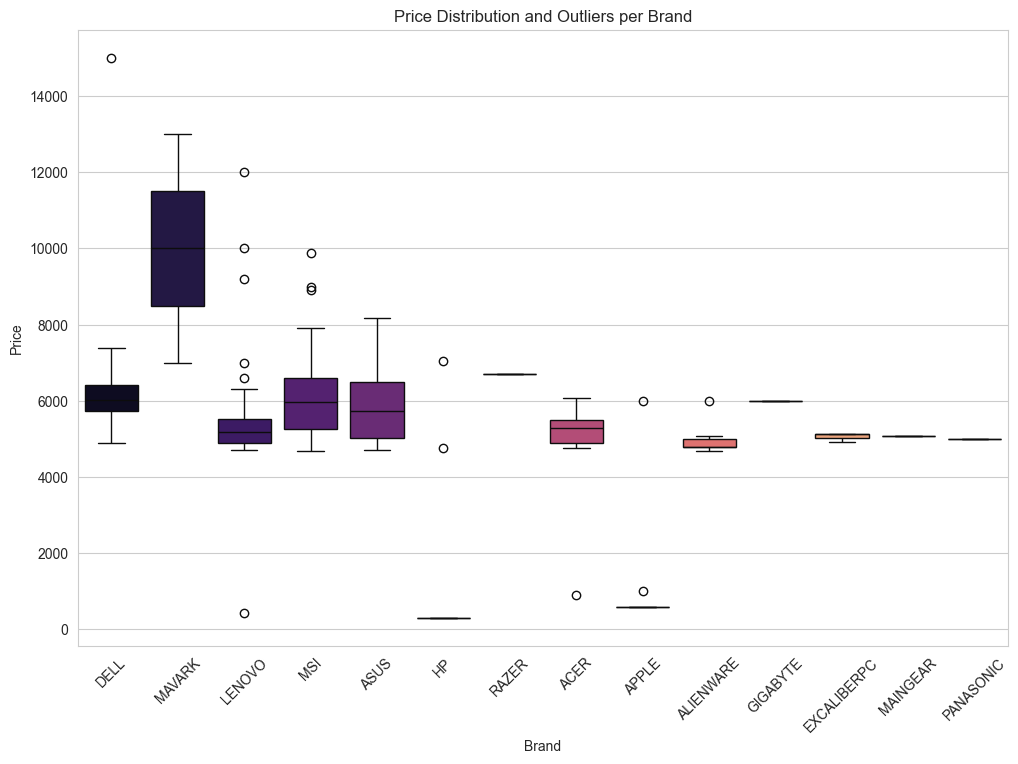

In [5]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df, x='Brand', y='Price', palette='magma')
plt.title('Price Distribution and Outliers per Brand')
plt.xticks(rotation=45)
plt.show()

Price Distribution & Outlier Detection (Boxplot)
This boxplot reveals the spread of prices across different brands and highlights significant Outliers:

DELL: Shows the most extreme outlier, with a workstation priced at $14,999. This explains why Dell had the highest "Average Price" in previous charts.

MSI: Has a higher median price compared to others, which is expected as it focuses on High-performance Gaming laptops.

Price Consistency: Brands like ASUS and LENOVO show a more "compact" price range, indicating they target the mid-range market more consistently.

Insight: When calculating averages for this dataset, the Median would be a more reliable measure than the Mean due to these extreme price variations in brands like Dell.

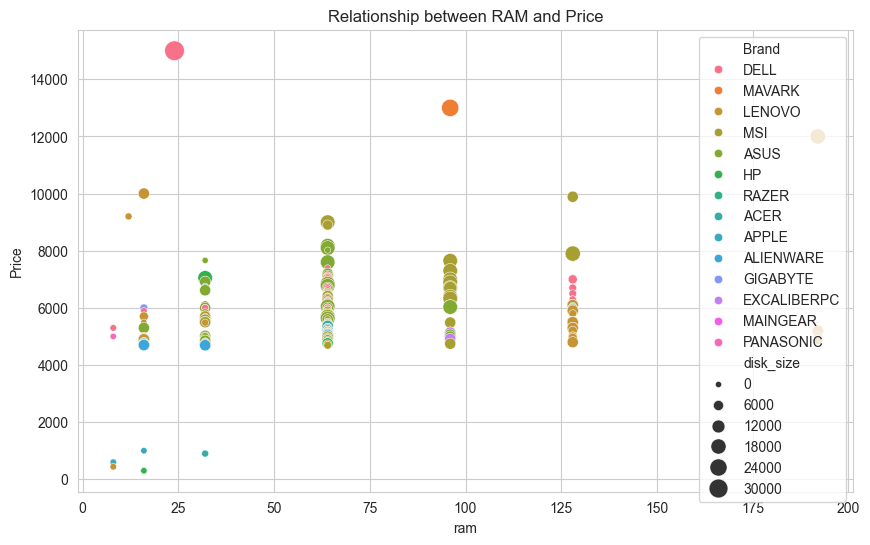

In [6]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='ram', y='Price', hue='Brand', size='disk_size', sizes=(20, 200))
plt.title('Relationship between RAM and Price')
plt.show()

🔍 In-Depth Analysis: RAM vs. Price Relationship
This scatter plot provides a multi-dimensional view of the laptop market. While a general upward trend exists, several critical patterns emerge:

1. The "Hidden Specs" Factor (Vertical Variance): We observe significant price gaps between laptops with the same RAM capacity (e.g., at 32GB and 64GB). This indicates that RAM is not the sole price driver. High-end components like NVIDIA RTX 4090/5090 GPUs, OLED Displays, and Core Ultra 9 CPUs are likely responsible for pushing prices to the $5,000 - $10,000+ range despite having mid-to-high RAM.

2. Price Segregation by Brand:

High-End Dominance: MSI and DELL (represented by the top dots) dominate the professional workstation and gaming tiers.

Mainstream Cluster: The bottom-left corner shows a dense concentration of laptops with 8GB to 32GB RAM priced below $2,500, representing the bulk of consumer-grade units.

3. The Extreme Performance Tier (Outliers):
The lone point at the top right (128GB RAM / ~$15,000) represents a specialized Mobile Workstation. This is a rare, niche product where extreme RAM and storage configurations drive the cost to its maximum.

4. Conclusion:
While a Positive Correlation exists, the price is heavily influenced by the "Package" (GPU + CPU + Display) rather than just the RAM count. In the premium segment, hardware specialized for 3D rendering or AI development creates these unique price spikes.